In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import AIMessage, HumanMessage
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

In [3]:
llm = ChatGroq(model="qwen/qwen3-32b", groq_api_key=GROQ_API_KEY)

In [4]:
arxiv = ArxivQueryRun(api_wrapper=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500))
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500))
tavily = TavilySearchResults()

C:\Users\Prashant\AppData\Local\Temp\ipykernel_29188\3212235632.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [5]:
tools = [arxiv, wiki, tavily]

In [6]:
llm_with_tools = llm.bind_tools(tools=tools)

In [7]:
llm_with_tools.invoke([HumanMessage(content="What is recent news in AI in 2026?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news 2026'},
  'id': 'xarrfecn9',
  'type': 'tool_call'}]

### Final Creation of Chat Bot

In [8]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [9]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [10]:
builder = StateGraph(State)
builder.add_node("llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))
builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", tools_condition)
builder.add_edge("tools", END)

In [11]:
graph = builder.compile()

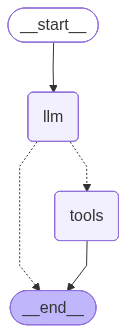

In [12]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
## Arxiv
messages = graph.invoke({"messages": HumanMessage(content="What is attention is all you need?")})
for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is attention is all you need?
================================== Ai Message ==================================
Tool Calls:
  arxiv (11dy8sc26)
 Call ID: 11dy8sc26
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [14]:
## Tavily
messages = graph.invoke({"messages": HumanMessage(content="What is Generative AI?")})
for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is Generative AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (jm98brhz5)
 Call ID: jm98brhz5
  Args:
    query: Generative AI definition and examples
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "20 Examples of Generative AI Applications Across Industries", "url": "https://www.coursera.org/articles/generative-ai-applications", "content": "## What is generative AI?\n\nGenerative AI is artificial intelligence designed to create unique text or image results in response to user prompts. The technology uses machine learning to return an output based on the user’s prompt. AI engineers train the technology using large data sets, which the model consults when determining the best possible answer to a prompt. Another way to look at generative AI is as 

In [15]:
## Normal LLM
messages = graph.invoke({"messages": HumanMessage(content="What is 2 + 2?")})
for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is 2 + 2?
================================== Ai Message ==================================

The sum of 2 and 2 is **4**.


In [16]:
## Wiki
messages = graph.invoke({"messages": HumanMessage(content="What is Vasco D Gama?")})
for message in messages["messages"]:
    message.pretty_print()


================================ Human Message =================================

What is Vasco D Gama?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (f8n9mkqyq)
 Call ID: f8n9mkqyq
  Args:
    query: Vasco da Gama
================================= Tool Message =================================
Name: wikipedia

Page: Vasco da Gama
Summary: Vasco da Gama ( VAS-koo də GA(H)M-ə, European Portuguese: [ˈvaʃku ðɐ ˈɣɐmɐ]; c. 1460s – 24 December 1524) was a Portuguese mariner, explorer and nobleman. His discovery of the first direct maritime route between Europe and India via the Cape of Good Hope and across the Indian Ocean from Malindi in Kenya to Kozhikode was to open up European exploration of, and commerce with, India, and is considered a landmark event and a turning point in world history.
Da Gama's firs
